# Técnicas e Instrumentación en Psicofisiología
Elaborado por el Mtro. Angel Jacobo para la Facultad de Medicina y Psicología, Universidad Autónoma de Baja California.


# Proyecto Final: Procesamiento de Bioseñales, Sueño

En este último cuaderno, el alumno pondrá en práctica las habilidades desarrolladas durante ejercicios anteriores para estudiar y extraer conclusiones sobre un conjunto de bioseñales registradas durante el sueño.

El alumno deberá explorar las características de las señales, los periodos de registro, y considerar variables como el ruido para realizar el procesamiento pertinente.

La visualización de datos está basada en el ejemplo provisto por Chambon et al. (2018), puede leerse en: https://mne.tools/stable/auto_tutorials/clinical/60_sleep.html


##Funciones de apoyo
Ejecute estas celdas para preparar algunas características del ambiente que serán necesarias para la práctica

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 27.7 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


Using default location ~/mne_data for PHYSIONET_SLEEP...


/tmp/ipykernel_18178/978090204.py:16: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_data.set_annotations(subject_annotations)


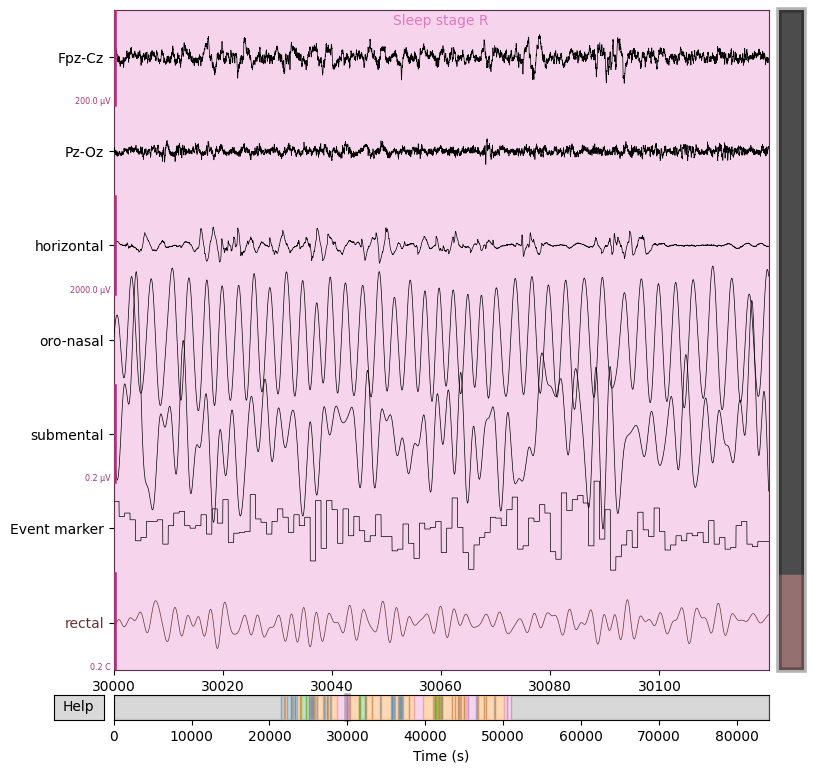

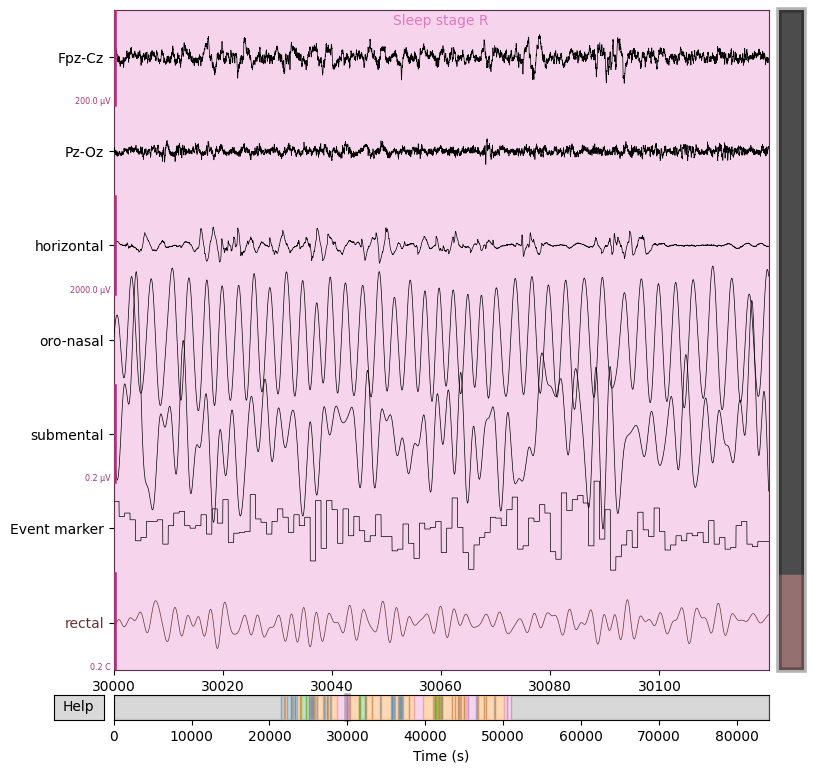

In [20]:
import mne
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets.sleep_physionet.age import fetch_data
subjects = [1]  # may vary
recs = [1]  # may vary

subject_data = fetch_data(subjects, recs)
raw_data = read_raw_edf(
    subject_data[0][0],
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error",  # ignore issues with stored filter settings
)

raw_data.set_annotations(subject_annotations)

raw_data.plot(start=30000, duration=120, scalings=dict(eeg=1e-4, resp=1e3, eog=1e-3, emg=1e-7, misc=1e-1),)

## Características del conjunto de datos (dataset)

Para este proyecto, trabajaremos con el conjunto de datos de sueño (Kemp, 2000) almacenados en PhysioBank (Goldberger et al., 2000), incluido en la biblioteca MNE.
Se trata de registros polisomnográficos que incluyen información de electroencefalograma, frecuencia respiratoria, y temperatura rectal.

Puede leer todas las especificaciones en
https://physionet.org/content/sleep-edfx/1.0.0/


Será especialmente útil leer el archivo SC-subjects.xls, que contiene información de los sujetos de estudio.